# 로지스틱 회귀 분석 소개 

- 로지스틱 회귀 모델에서 모델의 복잡성과 정규화 사이의 균형을 조정하는 중요한 역할을 하는 `C`
- `C`는 정규화의 강도를 조절, 이는 정규화 항의 역수로 정의된다. 
- 모델의 손실 함수는 크게 두부분으로 구성되는데, 하나는 예측값과 실제값의 차이를 나타내는 교차 엔트로피 부분, 다른 하나는 모델의 복잡성에 대한 패널티를 부과하는 정규화 항이다. 

### 1. 단일 데이터에 대한 Cross Entropy 식
하나의 데이터 샘플에 대한 크로스 엔트로피 오차 수식은 다음과 같습니다.

$$ H(y, \hat{y}) = - \left( y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right) $$

### 2. 전체 데이터셋의 Loss 식 (비용 함수)
실제 모델을 학습할 때는 하나의 샘플이 아닌, 전체 데이터($n$개)의 오차를 평균 내어 전반적인 손실(Loss)을 측정합니다. 모델은 이 손실 함수의 결과값을 최소화하는 방향으로 학습을 진행합니다.

$$ \text{Loss} = - \frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right] $$

- $n$: 전체 데이터의 개수
- $y_i$: 실제 정답 레이블 (0 또는 1)
- $\hat{y}_i$: 모델이 정답이 1일 것이라고 예측한 확률 (0에서 1 사이의 값)

### 수식 쉽게 이해하기
공식이 복잡해 보이지만, 실제 데이터(정답)가 0인지 1인지에 따라 두 부분 중 한 부분만 계산되도록 만들어진 매우 똑똑한 공식입니다.

- **정답이 1일 때 ($y_i = 1$)**
  우측의 $(1 - y_i)$ 부분이 0이 되므로, 앞부분인 $- \log(\hat{y}_i)$만 남습니다. 모델이 정답을 1(100%)로 정확히 예측하면 손실이 0이 되지만, 0으로 잘못 예측하면 손실값(페널티)이 무한대로 커집니다.
- **정답이 0일 때 ($y_i = 0$)**
  좌측의 $y_i$ 부분이 0이 되므로, 뒷부분인 $- \log(1 - \hat{y}_i)$만 남습니다. 모델이 정답을 0으로 맞게 예측하면 손실이 0이 됩니다.

**왜 이 식을 사용할까요?**
로지스틱 회귀에 기존 선형 회귀처럼 MSE(평균 제곱 오차)를 사용하게 되면, 오차 그래프가 구불구불한 웅덩이(Non-convex) 형태로 만들어져 가장 오차가 적은 지점을 찾기 어렵습니다. 하지만 위 로그(log) 함수가 들어간 Loss 수식을 적용하면 부드럽고 둥근 오목한 밥그릇(Convex) 모양이 되어 모델이 쉽게 최저 오차점을 찾아갈 수 있습니다.

### 추가 자료
- [Wikipedia: Cross entropy](https://en.wikipedia.org/wiki/Cross_entropy#Cross-entropy_loss_function_and_logistic_regression)
- [Scikit-Learn: Logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)

`LogisticRegression` 모델에서 중요한 하이퍼파라미터인 `C`의 의미와 역할, 그리고 머신러닝에서 과적합을 방지하는 핵심 기법인 Ridge(릿지)와 **Lasso(라쏘)** 정규화에 대해 상세히 설명해 드리겠습니다.

---

## 1. LogisticRegression의 `C` 매개변수 (Parameter)

사이킷런(Scikit-learn)의 `LogisticRegression` 함수에서 `C`는 **정규화(규제, Regularization)의 강도를 조절하는 매개변수**입니다.

* **데이터 타입:** `float` (실수형)
* **기본값(Default):** **1.0**

### 💡 `C`값의 핵심 의미: "규제 강도의 역수"

수학적으로 `C`는 규제 강도를 나타내는 $\lambda$ (또는 $\alpha$)의 역수입니다. 즉, $C = \frac{1}{\lambda}$ 의 관계를 가집니다. 따라서 값이 작을수록 규제가 강해지고, 값이 클수록 규제가 약해집니다.

* **`C` 값이 작을 때 (예: 0.01, 0.1):**
* **강한 규제:** 모델의 가중치(Weight)가 커지는 것을 엄격하게 제한합니다.
* **효과:** 모델이 단순해지며, 학습 데이터에 대한 정확도는 조금 떨어질 수 있지만 **과적합(Overfitting)을 방지**하여 새로운 데이터에 대한 일반화 성능을 높입니다.


* **`C` 값이 클 때 (예: 10, 100):**
* **약한 규제:** 가중치에 대한 제한을 느슨하게 합니다.
* **효과:** 모델이 학습 데이터의 패턴을 최대한 세밀하게 학습합니다. 데이터가 복잡할 때 유용하지만, 학습 데이터에만 과도하게 맞춰지는 **과적합이 발생할 위험**이 커집니다.



---

## 2. 정규화(Regularization)란?

정규화는 머신러닝 모델이 학습 데이터에 너무 과하게 맞춰져서(과적합) 새로운 데이터를 제대로 예측하지 못하는 현상을 막기 위한 기법입니다. 모델의 비용 함수(Cost Function)에 **페널티(Penalty)** 항목을 추가하여, 모델이 학습하면서 가중치($w$)를 너무 크게 갖지 못하도록 억제합니다.

이 페널티를 부여하는 방식에 따라 **Ridge**와 **Lasso**로 나뉩니다.

---

## 3. Ridge 정규화 (L2 규제)

Ridge(릿지) 정규화는 가중치의 **제곱합**을 페널티로 부여하는 방식입니다. 이를 **L2 규제**라고도 부릅니다.

### 📐 수식

비용 함수에 아래와 같은 페널티 항을 더합니다. (여기서 $\alpha$는 규제 강도입니다.)

$$ Cost = Loss + \alpha \sum_{j=1}^{p} w_j^2 $$

### 🔍 주요 특징

* **가중치 축소:** 모든 특성(Feature)의 가중치를 0에 가깝게 전반적으로 줄여줍니다.
* **0이 되지는 않음:** 가중치가 한없이 작아지기는 하지만, **완전히 0이 되지는 않습니다.** 즉, 처음 입력된 모든 특성을 끝까지 안고 갑니다.
* **다중공선성 방지:** 입력 변수들 간의 상관관계가 높을 때(다중공선성 문제), 특정 변수에 가중치가 몰리는 것을 막고 여러 변수에 가중치를 분산시켜 모델을 안정적으로 만듭니다.

---

## 4. Lasso 정규화 (L1 규제)

Lasso(라쏘) 정규화는 가중치의 **절댓값의 합**을 페널티로 부여하는 방식입니다. 이를 **L1 규제**라고도 부릅니다.

### 📐 수식

비용 함수에 다음과 같은 페널티 항을 더합니다.

$$ Cost = Loss + \alpha \sum_{j=1}^{p} |w_j| $$

### 🔍 주요 특징

* **특성 선택 (Feature Selection):** Lasso의 가장 큰 특징은 영향력이 적은 특성의 가중치를 **완전히 0**으로 만들어 버린다는 것입니다.
* **희소 모델 (Sparse Model):** 결과적으로 예측에 정말 중요한 소수의 변수만 살아남게 됩니다. 불필요한 노이즈 변수가 많은 데이터셋에서 매우 유용합니다.
* **직관적인 해석:** 중요한 변수만 남기 때문에, 결과 도출 후 "어떤 변수가 모델에 영향을 미쳤는지" 사람이 해석하기 훨씬 쉬워집니다.

---

## 📊 Ridge vs Lasso 요약 비교

| 구분 | Ridge (L2 규제) | Lasso (L1 규제) |
| --- | --- | --- |
| **페널티 방식** | 가중치의 제곱합 ($w^2$) | 가중치의 절댓값 합 ($\|w$) |
| **가중치가 0이 되는가?** | 아니오 (0에 가까워질 뿐임) | **예 (특정 가중치는 완전히 0이 됨)** |
| **주요 효과** | 가중치 분산, 다중공선성 완화 | 중요한 특성만 남김 (Feature Selection) |
| **언제 주로 쓰는가?** | 대부분의 변수가 다 조금씩 중요할 때 | 쓸모없는 변수가 많아 솎아내야 할 때 |

`LogisticRegression` 함수에서는 `penalty='l2'` (Ridge 방식, 기본값) 또는 `penalty='l1'` (Lasso 방식) 파라미터를 통해 어떤 정규화 방식을 사용할지 선택할 수 있으며, 이 두 방식의 강도를 조절하는 것이 바로 앞서 설명한 `C` 매개변수입니다.

# Example

- LogisticRegression

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 랜덤변수를 이용해 분류용 가상 데이터 생성 
X, y = make_classification(n_samples=1000,  # 샘플 수 증가
                           n_features=20,  # 특성 수 증가
                           n_informative=15,  # 유익한 특성의 수
                           n_redundant=5,  # 중복 특성의 수
                           n_clusters_per_class=2,  # 클래스 당 클러스터 수
                           weights=[0.7, 0.3],  # 클래스 비율 조정
                           flip_y=0.05,  # 레이블 노이즈 비율
                           class_sep=1.5,  # 클래스를 분리하는 정도
                           random_state=42,
                           n_classes=2)

# 데이터를 훈련 세트와 테스트 세트로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

from sklearn.linear_model import LogisticRegression

# 로지스틱 회귀 모델 초기화
model = LogisticRegression(solver='liblinear')
model

(800, 20)
(800,)
(200, 20)
(200,)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

`LogisticRegression` 모델에서 `solver` 매개변수는 **비용 함수(Cost Function)를 최소화하여 최적의 가중치를 찾아내는 '계산 알고리즘(최적화 방식)'을 결정**하는 역할을 합니다.

쉽게 말해, 산 정상에서 골짜기(오차가 가장 적은 지점)로 내려갈 때 "어떤 길과 보폭으로 내려갈 것인가?"를 정해주는 내비게이션 엔진이라고 볼 수 있습니다.

데이터의 크기, 다중 클래스 분류 여부, 그리고 앞서 설명해 드린 **어떤 정규화(L1, L2)를 사용할 것인지**에 따라 적절한 `solver`를 선택해야 합니다.

---

## 주요 Solver의 종류와 특징

### 1. `lbfgs` (기본값)

* **특징:** 성능과 속도 면에서 균형이 잘 잡혀 있어 사이킷런의 기본(Default) 알고리즘으로 사용됩니다.
* **지원 규제:** L2 규제(Ridge), 규제 없음(None)
* **제약:** **L1 규제(Lasso)를 지원하지 않습니다.** 따라서 `penalty='l1'`을 설정하고 싶다면 solver를 다른 것으로 바꿔야 합니다.
* **추천 상황:** 데이터셋의 크기가 작거나 중간 정도일 때 가장 무난하게 사용합니다.

### 2. `liblinear`

* **특징:** 아주 전통적이고 많이 쓰이는 최적화 알고리즘입니다.
* **지원 규제:** L1 규제(Lasso), L2 규제(Ridge) 모두 지원
* **제약:** 다중 클래스 분류(클래스가 3개 이상) 시, '이것 아니면 나머지(One-vs-Rest)' 방식으로 쪼개서 계산하므로 다중 클래스 문제에서는 성능이 약간 떨어질 수 있습니다. 데이터가 너무 크면 속도가 매우 느려집니다.
* **추천 상황:** **L1 규제를 써야 하거나**, 데이터셋의 크기가 작을 때 추천합니다.

### 3. `saga`

* **특징:** 대용량 데이터를 빠르게 처리하기 위해 확률적 경사하강법(SGD)을 개선한 알고리즘입니다.
* **지원 규제:** L1 규제, L2 규제, Elastic-Net(L1+L2 혼합) 모두 지원
* **추천 상황:** **데이터의 크기가 매우 클 때**, 그리고 대용량 데이터에서 L1 규제를 사용하고 싶을 때 가장 훌륭한 선택지입니다.

### 4. `sag`

* **특징:** `saga`의 이전 버전으로, 마찬가지로 대용량 데이터에 적합합니다.
* **지원 규제:** L2 규제(Ridge), 규제 없음
* **제약:** L1 규제를 지원하지 않습니다. 최근에는 보통 `sag`보다는 기능이 많은 `saga`를 더 선호하는 편입니다.

### 5. `newton-cg` / `newton-cholesky`

* **특징:** 미분의 미분(2차 미분)까지 계산하여 매우 정교하게 최적점을 찾아갑니다.
* **지원 규제:** L2 규제(Ridge), 규제 없음
* **제약:** 계산이 매우 복잡하여 특성(Feature)의 개수가 많아지면 속도가 기하급수적으로 느려집니다. L1 규제를 지원하지 않습니다.
* **추천 상황:** 다중 클래스 분류(Multinomial)에서 매우 정교한 확률 값이 필요할 때 간혹 사용됩니다. (`newton-cholesky`는 샘플 수는 엄청 많고 특성 수는 적을 때 유리합니다.)

---

## 📊 상황별 Solver 선택 가이드

| 상황 및 조건 | 가장 적합한 Solver |
| --- | --- |
| **일반적인 상황 (작은~중간 데이터, L2 규제)** | `lbfgs` (기본값 유지) |
| **L1 규제(Lasso)를 사용하고 싶을 때** | `liblinear` (소형), `saga` (대형) |
| **데이터 크기가 매우 클 때 (수만 건 이상)** | `saga` 또는 `sag` |
| **다중 클래스(3개 이상 정답) 분류 문제** | `lbfgs`, `saga`, `newton-cg` |

> **실무 꿀팁:** 코드를 돌리다가 *"Solver lbfgs supports only 'l2' or 'none' penalties"* 라는 에러가 발생한다면, `penalty='l1'`을 설정해 놓고 기본값인 `lbfgs`를 그대로 두었기 때문입니다. 이때는 `solver='liblinear'` 등으로 명시적으로 바꿔주시면 즉시 해결됩니다.

In [2]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score

# K-Fold 교차 검증 설정
kf = KFold(n_splits=5, shuffle=True, random_state=40)

# C 값의 후보 리스트
c_list = [10e-7, 10e-6, 10e-5, 10e-4, 10e-3, 10e-2, 10e-1, 1, 10, 10**2]
scores_list = []

# 각 C에 대한 교차 검증 수행
for c_val in c_list:
    # 로지스틱 회귀 모델 객체 정의, C 값 설정
    logreg_model = LogisticRegression(C=c_val, solver='liblinear', random_state=42)
    # 교차검증, 분류 문제이므로 'accuracy'를 사용
    scores = cross_val_score(logreg_model, X_train, y_train, scoring='accuracy', cv=kf)
    # 평균 점수 저장
    scores_list.append(np.mean(scores))

print('모델의 성능: ', scores_list)

모델의 성능:  [np.float64(0.7749999999999999), np.float64(0.7825), np.float64(0.81125), np.float64(0.86), np.float64(0.8949999999999999), np.float64(0.9025000000000001), np.float64(0.89375), np.float64(0.89375), np.float64(0.8925000000000001), np.float64(0.8925000000000001)]


In [3]:
# 최적 alpha 값 및 성능 확인
best_score = max(scores_list) # scores_list에서 최고득점
print(f"Best Score: {best_score}")

optimal_c = c_list[np.argmax(scores_list)] # 최고득점에서의 C의 값
print(f"Optimal C: {optimal_c}")

Best Score: 0.9025000000000001
Optimal C: 0.1


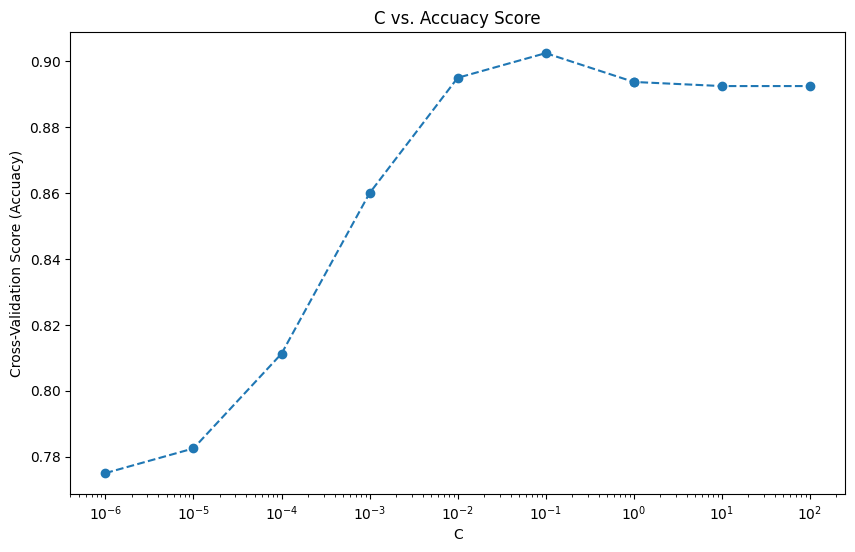

In [4]:
import matplotlib.pyplot as plt

# 결과 시각화
plt.figure(figsize=(10,6))
plt.plot(c_list, scores_list, marker='o', linestyle='--')
plt.xlabel('C')
plt.ylabel('Cross-Validation Score (Accuacy)')
plt.title('C vs. Accuacy Score')
plt.xscale('log')
plt.show()